# Star Sprite Atlas Export

Extracts star cutouts from the star-only FITS image, packs them into a sprite atlas PNG,
and writes `stars.json` + `nebula.png` to `export/`.

**Inputs**
- `matches.parquet` — crossmatch catalog (20 k sources)
- `test_solved_star.fits` — star-only image (StarNet output)
- `test_solved.fits` — original plate-solved image (for nebula)

**Outputs** (`export/`)
- `stars_atlas.png` — RGBA sprite grid
- `stars.json` — positions + UV + photometry
- `nebula.png` — original minus star-only

In [219]:
import sys, os, json, warnings
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
import math

## 1. Configuration

In [265]:
MATCHES_PATH   = "matches.parquet"
STAR_FITS_PATH = "test_solved_star.fits"
ORIG_FITS_PATH = "test_solved.fits"
EXPORT_DIR     = "export"

MAX_STARS   = 16_384   # cap for atlas
TRANSFORM   = "log10"
DEPTH_COEFF = 0.5   # depth span = DEPTH_COEFF * IMG_W scene units per log10-unit
CROP_FRAC = 0.8


os.makedirs(EXPORT_DIR, exist_ok=True)
print(f"Export directory: {EXPORT_DIR}/")

Export directory: export/


## 2. Load data

In [266]:
matches = pd.read_parquet(MATCHES_PATH)
print(f"Catalog: {len(matches)} sources")

# Load star-only image — keep RGB, shape (3, H, W)
with fits.open(STAR_FITS_PATH) as hdul:
    star_data = hdul[0].data.astype(np.float32)
    print(f"Star FITS shape: {star_data.shape}  dtype: {hdul[0].data.dtype}")

if star_data.ndim == 3:
    # (3, H, W) → keep as RGB, normalise to [0, 1]
    star_rgb = star_data / (star_data.max() + 1e-9)   # shape (3, H, W)
    IMG_H, IMG_W = star_rgb.shape[1], star_rgb.shape[2]
else:
    # grayscale fallback
    star_mono = star_data / (star_data.max() + 1e-9)
    star_rgb = np.stack([star_mono, star_mono, star_mono], axis=0)
    IMG_H, IMG_W = star_data.shape

IMG_CX = IMG_W / 2.0
IMG_CY = IMG_H / 2.0
print(f"Star image: {IMG_W}×{IMG_H}  cx={IMG_CX}  cy={IMG_CY}")

# Load original for nebula (grayscale is fine)
with fits.open(ORIG_FITS_PATH) as hdul:
    orig_data = hdul[0].data.astype(np.float32)
    print(f"Orig FITS shape: {orig_data.shape}")

if orig_data.ndim == 3:
    orig_luma = (0.2126 * orig_data[0] + 0.7152 * orig_data[1] + 0.0722 * orig_data[2])
    orig_luma /= orig_luma.max() + 1e-9
    star_luma = (0.2126 * star_rgb[0] + 0.7152 * star_rgb[1] + 0.0722 * star_rgb[2])
else:
    orig_luma = orig_data / (orig_data.max() + 1e-9)
    star_luma = star_rgb[0]

DEPTH_SCALE = DEPTH_COEFF * IMG_W
print(f"DEPTH_SCALE = {DEPTH_COEFF} × {IMG_W} = {DEPTH_SCALE:.0f}")

Catalog: 20130 sources
Star FITS shape: (3, 3000, 3000)  dtype: uint8
Star image: 3000×3000  cx=1500.0  cy=1500.0
Orig FITS shape: (3, 3000, 3000)
DEPTH_SCALE = 0.5 × 3000 = 1500


## 3. Explore parallax distance distribution

Look at the histogram, then set `BG_DIST_PC` in the next cell
to a value clearly **beyond** the real parallax stars.

Parallax stars : 7243
No-parallax    : 12887
Distance range : 36.1 – 1097319.9 pc
log10 range    : 1.557 – 6.040

  p50:     1880.9 pc   log10=3.274
  p75:     3017.2 pc   log10=3.480
  p90:     4717.9 pc   log10=3.674
  p95:     6647.9 pc   log10=3.823
  p99:    17413.6 pc   log10=4.241


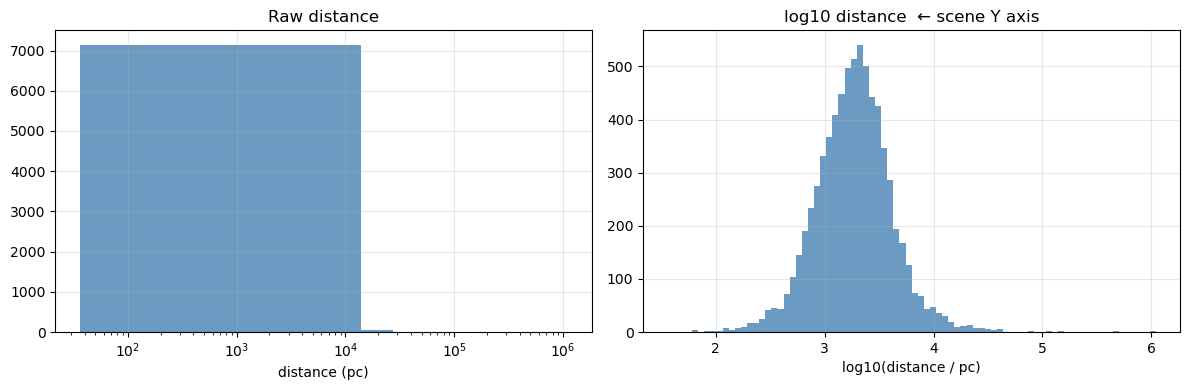

In [267]:
has_parallax = (
    matches["gaia_matched"] &
    matches["gaia_parallax"].notna() &
    (matches["gaia_parallax"] > 0)
)

dist_pc  = 1000.0 / matches.loc[has_parallax, "gaia_parallax"]
log_dist = np.log10(dist_pc)

print(f"Parallax stars : {has_parallax.sum()}")
print(f"No-parallax    : {(~has_parallax).sum()}")
print(f"Distance range : {dist_pc.min():.1f} – {dist_pc.max():.1f} pc")
print(f"log10 range    : {log_dist.min():.3f} – {log_dist.max():.3f}")
print()
for p in [50, 75, 90, 95, 99]:
    v = np.percentile(dist_pc, p)
    print(f"  p{p:2d}: {v:>10.1f} pc   log10={np.log10(v):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dist_pc, bins=80, color='steelblue', alpha=0.8)
axes[0].set_xlabel("distance (pc)")
axes[0].set_xscale("log")
axes[0].set_title("Raw distance")
axes[0].grid(True, alpha=0.3)
axes[1].hist(log_dist, bins=80, color='steelblue', alpha=0.8)
axes[1].set_xlabel("log10(distance / pc)")
axes[1].set_title("log10 distance  ← scene Y axis")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Set background distance

Pick a `BG_DIST_PC` that places no-parallax stars **behind** the real population.

In [268]:
# ← set this based on the histogram above
BG_DIST_PC = 2820

fn = np.log10
bg_z_scene = 0.0
print(f"BG_DIST_PC = {BG_DIST_PC:.0f} pc")
print(f"bg_z_scene = 0.0  (background placed at scene z=0)")
print(f"Parallax stars z-max = {-(log_dist.min() - np.log10(BG_DIST_PC)) * 0.5 * 3000:.1f}  (furthest toward camera)")
print(f"Parallax stars z-min = {-(log_dist.max() - np.log10(BG_DIST_PC)) * 0.5 * 3000:.1f}  (behind background)")

BG_DIST_PC = 2820 pc
bg_z_scene = 0.0  (background placed at scene z=0)
Parallax stars z-max = 2839.9  (furthest toward camera)
Parallax stars z-min = -3885.1  (behind background)


## 5. Apply distance transform & compute scene coordinates

In [269]:
matches = matches.copy()
matches["dist_pc"] = np.nan
matches.loc[has_parallax, "dist_pc"]  = 1000.0 / matches.loc[has_parallax, "gaia_parallax"]
matches.loc[~has_parallax, "dist_pc"] = BG_DIST_PC

# Coordinate system (standard Three.js: X right, Y up, Z toward viewer)
#   x_scene = pixel X offset from centre  (right is +X)
#   y_scene = pixel Y offset, flipped     (up is +Y)
#   z_scene = depth from background       (closer to camera = more positive Z)
matches["x_scene"] = matches["x"] - IMG_CX
matches["y_scene"] = -(matches["y"] - IMG_CY)   # flip: pixel-down → scene-down
matches["z_scene"] = -(fn(matches["dist_pc"]) - fn(BG_DIST_PC)) * DEPTH_SCALE

print(f"Scene X range: {matches['x_scene'].min():.1f} – {matches['x_scene'].max():.1f}")
print(f"Scene Y range: {matches['y_scene'].min():.1f} – {matches['y_scene'].max():.1f}")
print(f"Scene Z range: {matches['z_scene'].min():.1f} – {matches['z_scene'].max():.1f}  (bg z=0)")

Scene X range: -1499.5 – 1498.5
Scene Y range: -1498.5 – 1499.3
Scene Z range: -3885.1 – 2839.9  (bg z=0)


## 6. Cutout extraction

- Cutout half-size = `1.5 × fwhm`
- RGB color from original FITS
- Circular alpha mask: pixels beyond inscribed circle radius → transparent

In [270]:
def extract_cutout(rgb, cx, cy, fwhm):
    """Extract natural-size RGBA cutout. Returns (array, diameter) or (None, 0)."""
    half = int(min(15, 1.2 * fwhm))
    x0 = int(round(cx)) - half
    x1 = int(round(cx)) + half + 1
    y0 = int(round(cy)) - half
    y1 = int(round(cy)) + half + 1

    if x0 < 0 or y0 < 0 or x1 > rgb.shape[2] or y1 > rgb.shape[1]:
        return None, 0

    patch = np.transpose(rgb[:, y0:y1, x0:x1], (1, 2, 0)).copy()
    patch = (patch - patch.min()) / (patch.max() + 1e-9)

    d = 2 * half + 1
    pil = Image.fromarray((patch * 255).astype(np.uint8), mode="RGB").convert("RGBA")

    arr = np.array(pil)
    ys, xs = np.ogrid[:d, :d]
    dist = np.sqrt((xs - half) ** 2 + (ys - half) ** 2)
    arr[:, :, 3] = np.where(dist <= half, 255, 0).astype(np.uint8)
    return arr, d

# --- spatial filter: central 40% of image (both axes) ---
x_lo = IMG_CX - CROP_FRAC / 2 * IMG_W
x_hi = IMG_CX + CROP_FRAC / 2 * IMG_W
y_lo = IMG_CY - CROP_FRAC / 2 * IMG_H
y_hi = IMG_CY + CROP_FRAC / 2 * IMG_H

stellar = matches[matches["is_stellar"]].copy()
stellar = stellar[
    (stellar["x"] >= x_lo) & (stellar["x"] <= x_hi) &
    (stellar["y"] >= y_lo) & (stellar["y"] <= y_hi)
]
stellar = stellar.sort_values("flux", ascending=False).reset_index(drop=True)
stellar = stellar.head(MAX_STARS)
print(f"Stellar in central {CROP_FRAC*100:.0f}% region: {len(stellar)} (cap={MAX_STARS})")

cutouts = []
valid_idx = []

for i, row in stellar.iterrows():
    cut, d = extract_cutout(star_rgb, row["x"], row["y"], row["fwhm"])
    if cut is not None:
        cutouts.append((cut, d))
        valid_idx.append(i)

stars_df = stellar.loc[valid_idx].reset_index(drop=True)
diameters = [d for _, d in cutouts]
print(f"Valid cutouts: {len(cutouts)} (clipped {len(stellar) - len(cutouts)})")
print(f"Diameter range: {min(diameters)} - {max(diameters)} px")

Stellar in central 80% region: 11386 (cap=16384)
Valid cutouts: 11386 (clipped 0)
Diameter range: 3 - 31 px


## 7. Pack sprite atlas (RGBA)

In [271]:
# Shelf packing: sort by height desc, place row by row
ATLAS_W = 4096
atlas = np.zeros((ATLAS_W, ATLAS_W, 4), dtype=np.uint8)
x_cur, y_cur, row_h = 0, 0, 0

order = sorted(range(len(cutouts)), key=lambda i: cutouts[i][1], reverse=True)

px_x_list, px_y_list, px_w_list, px_h_list = [], [], [], []
placed_order = []

for idx in order:
    arr, d = cutouts[idx]
    if x_cur + d > ATLAS_W:
        y_cur += row_h
        x_cur = 0
        row_h = 0
    if y_cur + d > ATLAS_W:
        break
    atlas[y_cur:y_cur+d, x_cur:x_cur+d] = arr
    px_x_list.append(x_cur)
    px_y_list.append(y_cur)
    px_w_list.append(d)
    px_h_list.append(d)
    placed_order.append(idx)
    x_cur += d
    row_h = max(row_h, d)

# Reorder back to original star order
orig_to_placed = {orig: i for i, orig in enumerate(placed_order)}
stars_df = stars_df.iloc[placed_order].reset_index(drop=True)
stars_df = stars_df.assign(
    px_x=[px_x_list[i] for i in range(len(placed_order))],
    px_y=[px_y_list[i] for i in range(len(placed_order))],
    px_w=[px_w_list[i] for i in range(len(placed_order))],
    px_h=[px_h_list[i] for i in range(len(placed_order))],
)

# Trim atlas height
used_h = y_cur + row_h
atlas = atlas[:used_h, :]
print(f"Atlas: {ATLAS_W} x {used_h} px  ({len(placed_order)} sprites packed)")
print(f"Diameter range: {min(px_w_list)} - {max(px_w_list)} px")

atlas_path = os.path.join(EXPORT_DIR, "stars_atlas.png")
Image.fromarray(atlas, mode="RGBA").save(atlas_path)
print(f"Saved: {atlas_path}  ({os.path.getsize(atlas_path)/1024:.0f} KB)")

Atlas: 4096 x 178 px  (11386 sprites packed)
Diameter range: 3 - 31 px
Saved: export/stars_atlas.png  (1639 KB)


## 8. Preview atlas

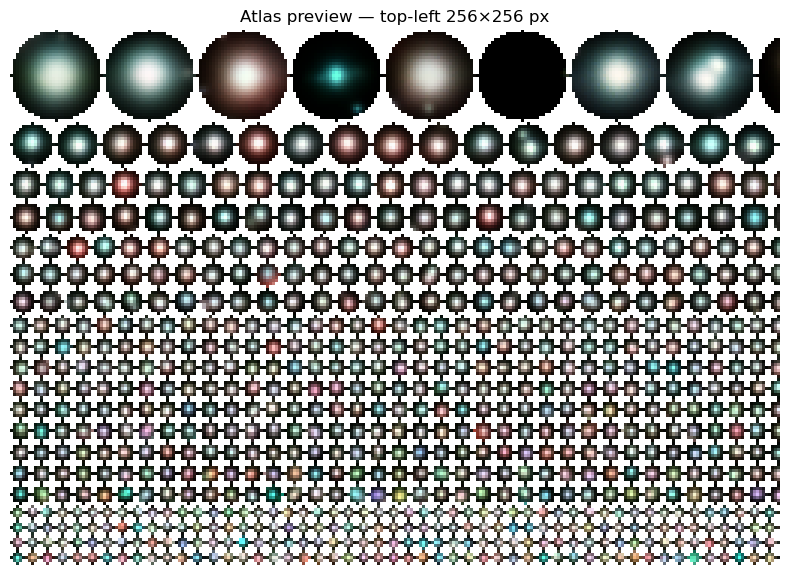

In [272]:
preview_px = 256
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(atlas[:preview_px, :preview_px], origin="upper")
ax.set_title(f"Atlas preview — top-left {preview_px}×{preview_px} px")
ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Export stars.json

In [273]:
meta = {
    "atlas": "stars_atlas.png",
    "transform": TRANSFORM,
    "img_cx": IMG_CX,
    "img_cy": IMG_CY,
    "bg_dist_pc": BG_DIST_PC,
    "bg_z_scene": round(bg_z_scene, 6),
}

star_records = []
for _, row in stars_df.iterrows():
    g_mag = None if pd.isna(row.get("gaia_g_mag")) else round(float(row["gaia_g_mag"]), 3)
    star_records.append({
        "x":    round(float(row["x_scene"]), 3),
        "y":    round(float(row["y_scene"]), 3),
        "z":    round(float(row["z_scene"]), 4),
        "px_x": int(row["px_x"]),
        "px_y": int(row["px_y"]),
        "px_w": int(row["px_w"]),
        "px_h": int(row["px_h"]),
        "flux": round(float(row["flux"]), 1),
        "fwhm": round(float(row["fwhm"]), 2),
        "g_mag": g_mag,
    })

output = {"meta": meta, "stars": star_records}
json_path = os.path.join(EXPORT_DIR, "stars.json")
with open(json_path, "w") as f:
    json.dump(output, f, separators=(",", ":"))

print(f"Saved: {json_path}  ({os.path.getsize(json_path) / 1024:.1f} KB)")
print(f"Stars exported: {len(star_records)}")
zs = [s["z"] for s in star_records]
print(f"Z (depth) range: {min(zs):.1f} – {max(zs):.1f}  (bg z={bg_z_scene:.1f})")

Saved: export/stars.json  (1290.5 KB)
Stars exported: 11386
Z (depth) range: -3862.4 – 2839.9  (bg z=0.0)


## 10. Export nebula.png (original − star_only)

Saved: export/nebula.png  (3000x3000 px)


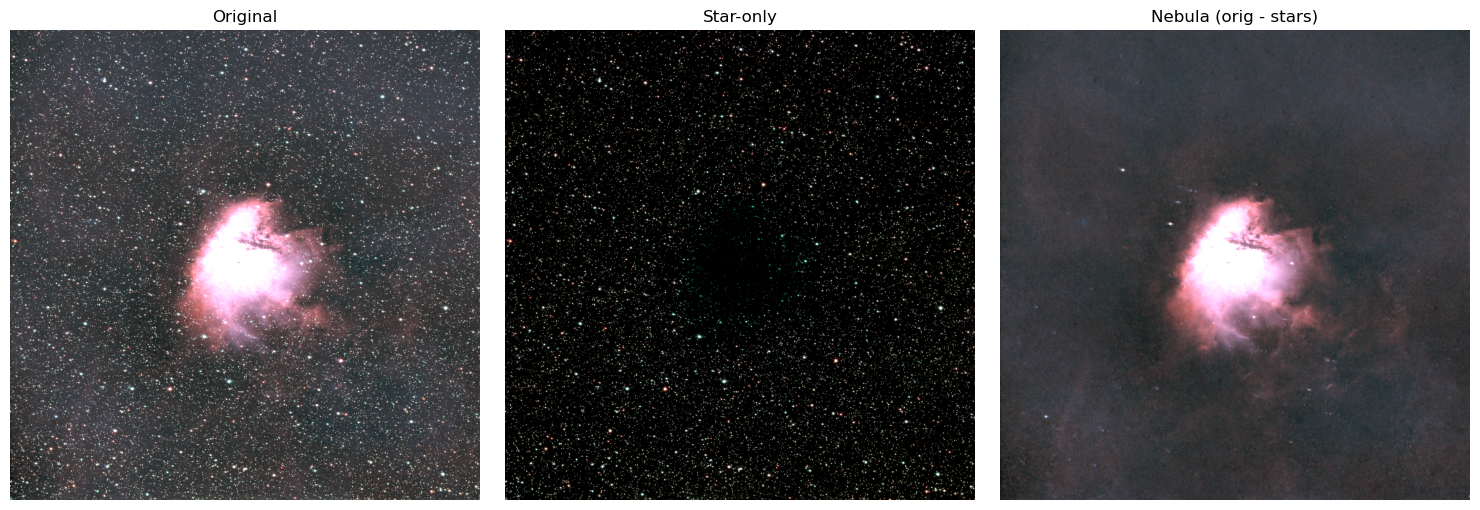

In [274]:
# orig_data is (3, H, W) — subtract star_rgb channel-wise, keep RGB
if orig_data.ndim == 3:
    orig_rgb_f = np.transpose(orig_data / (orig_data.max() + 1e-9), (1, 2, 0))  # (H, W, 3)
    star_rgb_f = np.transpose(star_rgb, (1, 2, 0))                               # (H, W, 3)
    nebula_rgb = np.clip(orig_rgb_f - star_rgb_f, 0.0, 1.0)
else:
    nebula_rgb = np.stack([np.clip(orig_luma - star_luma, 0.0, 1.0)] * 3, axis=-1)

nebula_uint8 = (nebula_rgb * 255).astype(np.uint8)

# Flip vertically: FITS row 0 = bottom of sky, PIL row 0 = top of PNG.
# Three.js flipY=true maps UV.y=0 → PNG bottom row = FITS row 0 = sky bottom.
# After flip, PNG row 0 = sky top, UV.y=1 = sky top = scene Y positive — correct.
nebula_flipped = nebula_uint8[::-1, :, :]

nebula_path = os.path.join(EXPORT_DIR, "nebula.png")
Image.fromarray(nebula_flipped, mode="RGB").save(nebula_path)
print(f"Saved: {nebula_path}  ({nebula_flipped.shape[1]}x{nebula_flipped.shape[0]} px)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
                           [orig_rgb_f, star_rgb_f, nebula_rgb],
                           ["Original", "Star-only", "Nebula (orig - stars)"]):
    ax.imshow(np.clip(img * 2, 0, 1), origin="lower")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. Summary

In [275]:
print("=" * 50)
print("Export complete")
print("=" * 50)
for fname in ["stars_atlas.png", "stars.json", "nebula.png"]:
    path = os.path.join(EXPORT_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {fname:<20} {size_kb:>8.1f} KB")
print(f"Stars in atlas : {len(star_records)}")
print(f"Atlas size     : {atlas.shape[1]} x {atlas.shape[0]} px  (RGBA)")
print(f"BG_DIST_PC     : {BG_DIST_PC:.0f} pc  →  z = {bg_z_scene:.4f}")
print(f"Coord system   : X=right  Y=up  Z=toward camera (depth)")

Export complete
  stars_atlas.png        1638.9 KB
  stars.json             1290.5 KB
  nebula.png            15548.5 KB
Stars in atlas : 11386
Atlas size     : 4096 x 178 px  (RGBA)
BG_DIST_PC     : 2820 pc  →  z = 0.0000
Coord system   : X=right  Y=up  Z=toward camera (depth)
